# **Задание 1**

In [1]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas
import numpy as np
import time

In [2]:
def f(x, y):
    return (x**2/800 - y**2/800 + 1/2)

In [3]:
# Создаем массивы X и Y
X = np.arange(-20, 20, 0.25)
Y = np.arange(-20, 20, 0.25)
X, Y = np.meshgrid(X, Y)

# Вычисляем значения Z по функции
Z = f(X, Y)

In [12]:
class NN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.05):
        self.learning_rate = learning_rate
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01

    def activate(self, x):
        # Функция активации PReLU
        return np.where(x > 0, x, 0.1 * x)

    def predict(self, x):
        # Прямое распространение: вход -> скрытый слой -> выход
        self.hidden_input = np.dot(x, self.weights_input_hidden)
        self.hidden_output = self.activate(self.hidden_input)
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output)
        return self.activate(self.final_input)

    def forward(self, x):
    # Прямое распространение
        return self.predict(x)

    def backward(self, x, y, output):
        # Обратное распространение
        output_error = y - output
        output_gradient = np.where(output > 0, 1, 0.1)
        output_delta = output_error * output_gradient

        hidden_error = np.dot(output_delta, self.weights_hidden_output.T)
        hidden_gradient = np.where(self.hidden_output > 0, 1, 0.1)
        hidden_delta = hidden_error * hidden_gradient

        # Обновление весов
        self.weights_hidden_output += self.learning_rate * np.dot(self.hidden_output.T.reshape(-1, 1), output_delta.reshape(1, -1))
        self.weights_input_hidden += self.learning_rate * np.dot(x.reshape(-1, 1), hidden_delta.reshape(1, -1))

    def mean_squared_error(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def accuracy(self, y_true, y_pred, threshold=0.1):
        return np.mean(np.abs(y_true - y_pred) < threshold)

    def train(self, X, Y, Z, epochs):
        for epoch in range(epochs):
            for i in range(len(Z)):
                x_input = np.array([X[i], Y[i]]) # Входные данные в виде массива
                output = self.forward(x_input) # Прямое распространение
                self.backward(x_input, Z[i], output) # Обратное распространение

            # Каждые 50 эпох
            if epoch % 50 == 0:
                predictions = self.predict(np.column_stack((X, Y)))
                loss = self.mean_squared_error(Z, predictions)
                acc = self.accuracy(Z, predictions)
                print(f'Epoch {epoch} - Loss: {loss:.4f}, Accuracy: {acc:.4f}') # Вывод потерь и точности (выборочно, каждые 50 эпох)

In [14]:
input_size = 2    # Количество входов
hidden_size = 30  # Размер скрытого слоя
output_size = 1   # Один выход

nn = NN(input_size=input_size, hidden_size=hidden_size, output_size=output_size, learning_rate=0.00001)

# Обучение нейронной сети
nn.train(X.flatten(), Y.flatten(), Z.flatten(), epochs=400)


Epoch 0 - Loss: 0.2758, Accuracy: 0.0420
Epoch 50 - Loss: 0.1064, Accuracy: 0.2207
Epoch 100 - Loss: 0.1154, Accuracy: 0.2094
Epoch 150 - Loss: 0.1195, Accuracy: 0.2050
Epoch 200 - Loss: 0.1206, Accuracy: 0.2038
Epoch 250 - Loss: 0.1209, Accuracy: 0.2036
Epoch 300 - Loss: 0.1210, Accuracy: 0.2034
Epoch 350 - Loss: 0.1210, Accuracy: 0.2034


In [15]:
# Прогоняем массив данных через обученную нейронную сеть
Z_nn = nn.predict(np.column_stack((X.flatten(), Y.flatten()))).reshape(X.shape)

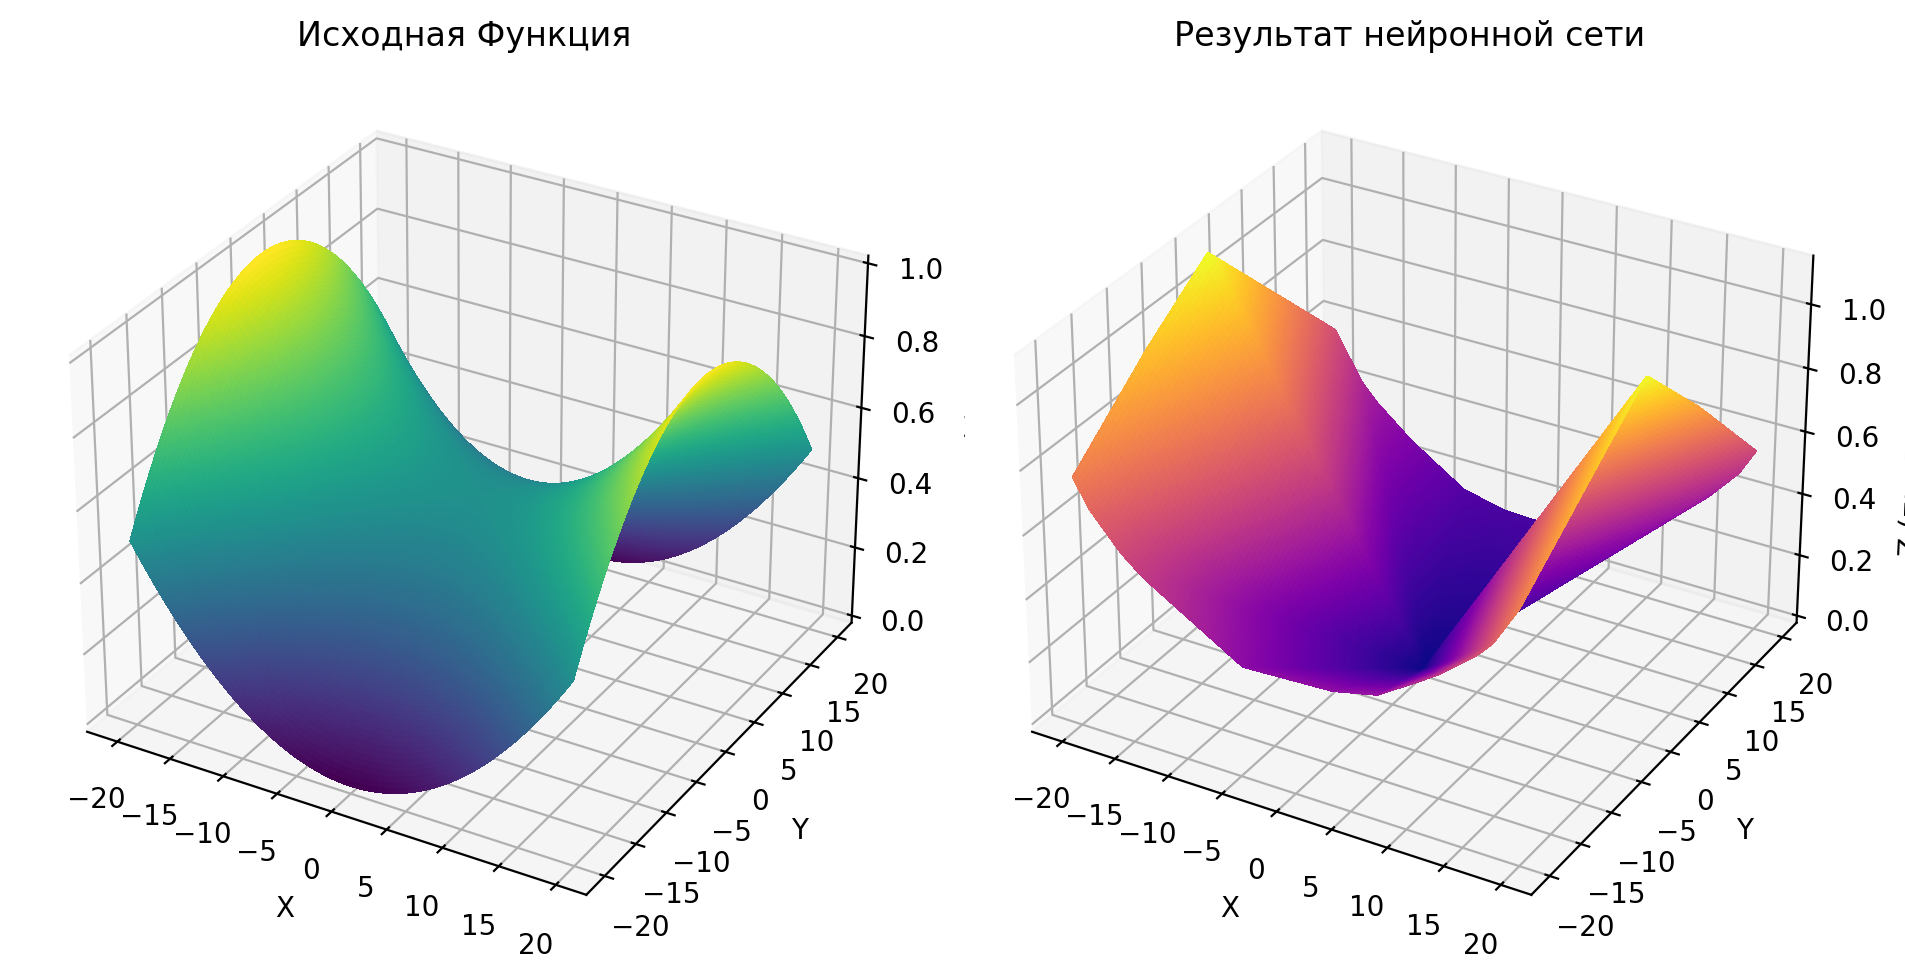

In [16]:
# Визуализация
fig = plt.figure(figsize=plt.figaspect(0.5), dpi=200)

# График исходной функции
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)
ax.set_title("Исходная Функция")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# График предсказаний нейронной сети
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_surface(X, Y, Z_nn, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)
ax.set_title("Результат нейронной сети")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z (предсказание)")

# Показать графики
plt.tight_layout()
plt.show()

# **Задание 3**

In [18]:
class TwoLayerNN1:
  def __init__(self, input_size, hidden_size, learning_rate=0.01):
    self.learning_rate = learning_rate

    # Инициализация весов
    self.weights_input_hidden = np.random.rand(input_size, hidden_size) * 0.01
    self.weights_hidden_output = np.random.rand(hidden_size) * 0.01
    self.hidden_layer_output = None

  def prelu(self, x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

  def prelu_derivative(self, x, alpha=0.1):
    return np.where(x > 0, 1, alpha)

  def prelu2(self, x, alpha=0.2):
    return np.where(x > 0, x, alpha * x)

  def prelu2_derivative(self, x, alpha=0.2):
    return np.where(x > 0, 1, alpha)

  def predict(self, x):
    # Прогон через нейронную сеть
    hidden_layer_input = np.dot(x, self.weights_input_hidden)
    self.hidden_layer_output = self.prelu(hidden_layer_input) # Первый слой с PReLU
    output = self.prelu2(np.dot(self.hidden_layer_output, self.weights_hidden_output)) # Второй слой с PReLU
    return output

  def forward(self, x):
    # Прямое распространение
    return self.predict(x)

  def backward(self, x, y, output):
    # Обратное распространение
    output_error = (y - output) * self.prelu2_derivative(output) # Используем производную PReLU2

    # Производная скрытого слоя с учетом PReLU
    hidden_error = np.dot(output_error, self.weights_hidden_output) * self.prelu_derivative(self.hidden_layer_output)

    # Обновление весов
    self.weights_hidden_output += self.learning_rate * self.hidden_layer_output * output_error
    self.weights_input_hidden += self.learning_rate * np.outer(x, hidden_error) # Используем np.outer для корректного обновления весов

  def train(self, X, Y, Z, epochs):
    # Обучение нейронной сети
    for epoch in range(epochs):
      for i in range(len(Z)):
        x_input = np.array([X[i], Y[i]]) # Входные данные в виде массива
        output = self.forward(x_input) # Прямое распространение
        self.backward(x_input, Z[i], output) # Обратное распространение

In [19]:
nn = TwoLayerNN1(input_size=2, hidden_size=5, learning_rate=0.00001) #0.00005

# Обучение нейронной сети
nn.train(X.flatten(), Y.flatten(), Z.flatten(), epochs=200)

# Прогоняем массив данных через обученную нейронную сеть
Z_nn = np.array([nn.predict(np.array([X.flatten()[i], Y.flatten()[i]])) for i in range(len(X.flatten()))]).reshape(X.shape)

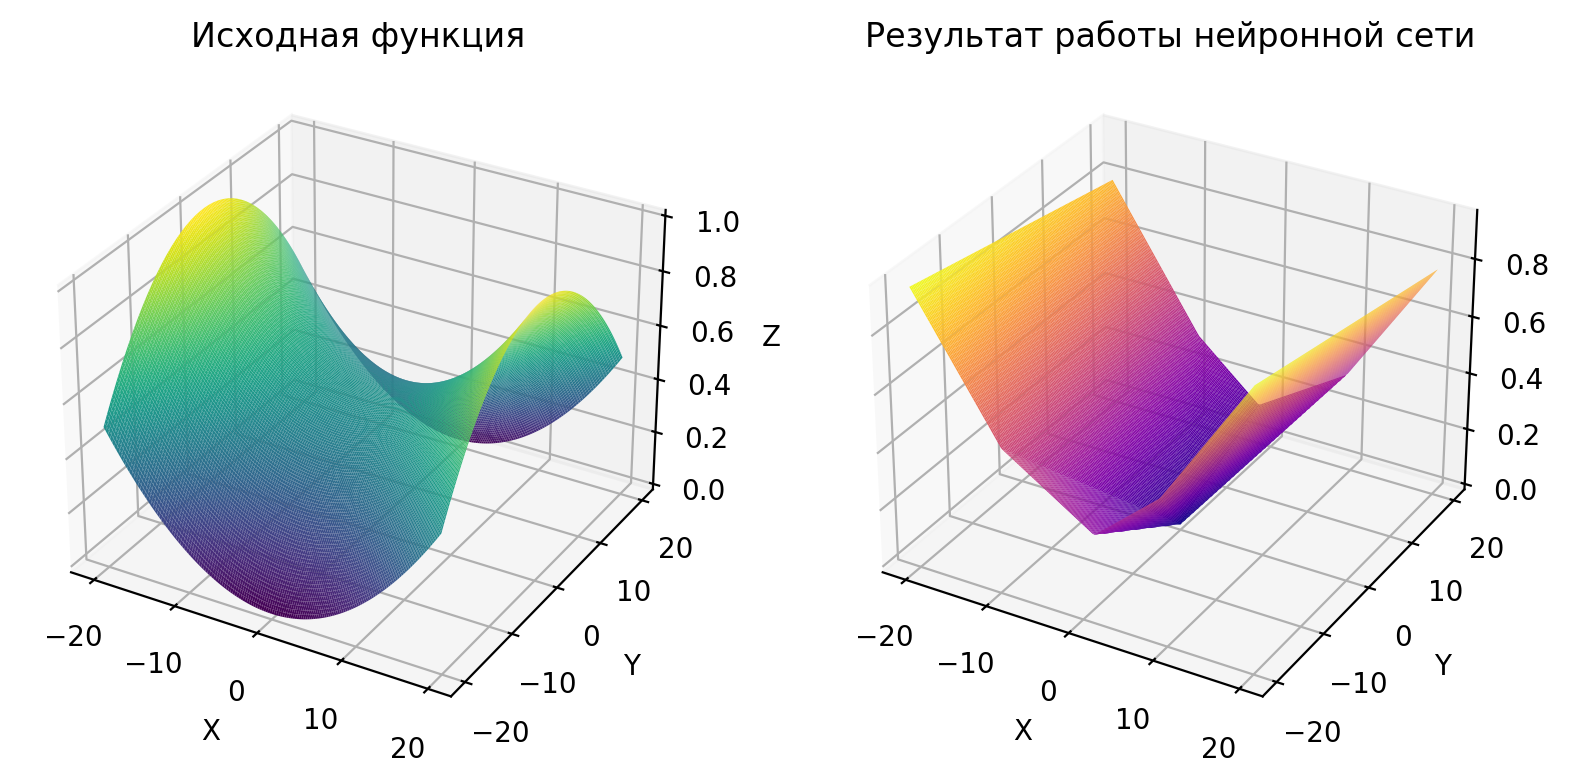

In [20]:
# Визуализация
fig = plt.figure(figsize=plt.figaspect(0.5), dpi=200)

# График исходной функции
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.viridis, edgecolor='none')
ax.set_title('Исходная функция')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# График предсказанной функции нейронной сетью
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, Z_nn, rstride=1, cstride=1, cmap=cm.plasma, edgecolor='none')
ax2.set_title('Результат работы нейронной сети')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.show()

# **Задание 2**

In [101]:
class NN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.05, activation_function='sigmoid', alpha=0.1):
        self.learning_rate = learning_rate # Устанавливаем скорость обучения
        self.activation_function = activation_function # Устанавливаем функцию активации
        self.alpha = alpha # Устанавливаем параметр alpha для PReLU
        # Инициализация весов с использованием метода Хавинша
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)

    def activate(self, x):
        # Выбор функции активации
        if self.activation_function == 'prelu':
            return np.where(x > 0, x, x * self.alpha) # PReLU
        elif self.activation_function == 'sigmoid':
            return 1 / (1 + np.exp(-x)) # Sigmoid
        else:
            raise ValueError('Неизвестная функция активации')

    def predict(self, x):
    # Прямой проход через сеть
        self.hidden_input = np.dot(x, self.weights_input_hidden) # Вычисляем входные данные скрытого слоя
        self.hidden_output = self.activate(self.hidden_input) # Применяем функцию активации к скрытому слою
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) # Вычисляем входные данные выходного слоя
        return self.activate(self.final_input) # Применяем функцию активации к выходному слою

    def forward(self, x):
    # Метод для выполнения прямого прохода
        return self.predict(x)

    def backward(self, x, y, output):
        # Метод для обратного распространения ошибки
        output_error = y - output # Вычисляем ошибку на выходе

        # Выбор производной функции активации
        if self.activation_function == 'sigmoid':
            output_gradient = output * (1 - output) # Производная Sigmoid
        elif self.activation_function == 'prelu':
            output_gradient = np.where(output > 0, 1, self.alpha) # Производная PReLU
        else:
            raise ValueError('Неизвестная функция активации')

        output_delta = output_error * output_gradient # Вычисляем дельту для выходного слоя
        hidden_error = np.dot(output_delta, self.weights_hidden_output.T) # Вычисляем ошибку на скрытом слое

        # Выбор производной функции активации для скрытого слоя
        if self.activation_function == 'sigmoid':
            hidden_gradient = self.hidden_output * (1 - self.hidden_output) # Производная Sigmoid
        elif self.activation_function == 'prelu':
            hidden_gradient = np.where(self.hidden_output > 0, 1, self.alpha) # Производная PReLU
        else:
            raise ValueError('Неизвестная функция активации')

        hidden_delta = hidden_error * hidden_gradient # Вычисляем дельту для скрытого слоя
        return output_delta, hidden_delta # Возвращаем дельты для выходного и скрытого слоев

    def mean_squared_error(self, y_true, y_pred):
        # Вычисление среднеквадратичной ошибки
        return np.mean((y_true - y_pred) ** 2)
    def train(self, X, Y, Z, epochs, optimizer, batch_size=32):
        loss_history = []
        n_samples = len(Z)
        for epoch in range(epochs):
            for i in range(0, n_samples, batch_size):
                x_batch = np.column_stack((X[i:min(i + batch_size, n_samples)], Y[i:min(i + batch_size, n_samples)]))
                y_batch = Z[i:min(i + batch_size, n_samples)].reshape(-1, 1)
                output = self.forward(x_batch)
                output_delta, hidden_delta = self.backward(x_batch, y_batch, output)
                optimizer.update(self, x_batch, output_delta, hidden_delta, batch_size)
            if epoch % 50 == 0:
                predictions = self.predict(np.column_stack((X, Y)))
                loss = self.mean_squared_error(Z.flatten(), predictions.flatten())
                loss_history.append(loss)
                print(f'Epoch {epoch} - Loss: {loss:.4f}')  # Вывод потерь
        return loss_history

class AdamOptimizer:
    def __init__(self, learning_rate=0.001):
        self.learning_rate = learning_rate
        self.m = None
        self.v = None
        self.t = 0
    def update(self, model, x, output_delta, hidden_delta, batch_size):
        if self.m is None:
            self.m = [np.zeros_like(model.weights_input_hidden), np.zeros_like(model.weights_hidden_output)]
            self.v = [np.zeros_like(model.weights_input_hidden), np.zeros_like(model.weights_hidden_output)]
        # Увеличиваем счетчик итераций
        self.t += 1
        # Считаем градиенты для весов
        grad_w_hidden = np.dot(model.hidden_output.T, output_delta) / batch_size
        grad_w_input = np.dot(x.T, hidden_delta) / batch_size
        # Обновляем моменты
        for i, (grad_w, w) in enumerate(zip([grad_w_input, grad_w_hidden], [model.weights_input_hidden, model.weights_hidden_output])):
            self.m[i] = 0.9 * self.m[i] + 0.1 * grad_w
            self.v[i] = 0.999 * self.v[i] + 0.001 * (grad_w ** 2)

            # Коррекция смещения
            m_hat = self.m[i] / (1 - 0.9 ** self.t)
            v_hat = self.v[i] / (1 - 0.999 ** self.t)
            # Обновление весов
            w += self.learning_rate * m_hat / (np.sqrt(v_hat) + 1e-8)
class AdaGradOptimizer:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.gradient_squares = None
    def update(self, model, x, output_delta, hidden_delta, batch_size):
        if self.gradient_squares is None:
            self.gradient_squares = [np.zeros_like(model.weights_input_hidden), np.zeros_like(model.weights_hidden_output)]
        grad_w_hidden = np.dot(model.hidden_output.T, output_delta) / batch_size
        grad_w_input = np.dot(x.T, hidden_delta) / batch_size
        for i, (grad_w, w) in enumerate(zip([grad_w_input, grad_w_hidden], [model.weights_input_hidden, model.weights_hidden_output])):
            self.gradient_squares[i] = 0.9 * self.gradient_squares[i] + 0.1 * (grad_w ** 2)
            w += (self.learning_rate / (np.sqrt(self.gradient_squares[i]) + 1e-8)) * grad_w
class NesterovOptimizer:
    def __init__(self, learning_rate=0.01, momentum=0.9):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.velocities = None
    def update(self, model, x, output_delta, hidden_delta, batch_size):
        if self.velocities is None:
            self.velocities = [np.zeros_like(model.weights_input_hidden), np.zeros_like(model.weights_hidden_output)]

        grad_w_hidden = np.dot(model.hidden_output.T, output_delta) / batch_size
        grad_w_input = np.dot(x.T, hidden_delta) / batch_size

        for i, (grad_w, w) in enumerate(zip([grad_w_input, grad_w_hidden], [model.weights_input_hidden, model.weights_hidden_output])):
            # Обновляем скорости
            self.velocities[i] = self.momentum * self.velocities[i] - self.learning_rate * grad_w

            # "Предварительный взгляд" на будущий градиент
            lookahead_w = w + self.momentum * self.velocities[i]

            # Обновляем веса с учетом предстоящего градиента
            w += self.momentum * self.velocities[i] - self.learning_rate * grad_w

In [102]:
# Визуализация и обучение модели
def plot_results(loss_history, optimizer_name, X, Y, Z, Z_nn):
    # Оригинальная функция
    ax1 = plt.subplot(2, 2, 2, projection='3d')
    ax1.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax1.set_title("Оригинальная Функция")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    # Предсказания модели
    ax2 = plt.subplot(2, 2, 3, projection='3d')
    ax2.plot_surface(X, Y, Z_nn, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)
    ax2.set_title("Результат работы нейронной сети")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")
    plt.tight_layout()
    plt.show()

Epoch 0 - Loss: 0.2530
Epoch 50 - Loss: 0.1801
Epoch 100 - Loss: 0.0531
Epoch 150 - Loss: 0.0520
Epoch 200 - Loss: 0.0530
Epoch 250 - Loss: 0.0544
Epoch 300 - Loss: 0.0557
Epoch 350 - Loss: 0.0569
Epoch 400 - Loss: 0.0579
Epoch 450 - Loss: 0.0587
Epoch 500 - Loss: 0.0594
Epoch 550 - Loss: 0.0600
Epoch 600 - Loss: 0.0605
Epoch 650 - Loss: 0.0609
Epoch 700 - Loss: 0.0613
Epoch 750 - Loss: 0.0616
Epoch 800 - Loss: 0.0618
Epoch 850 - Loss: 0.0621
Epoch 900 - Loss: 0.0623
Epoch 950 - Loss: 0.0625


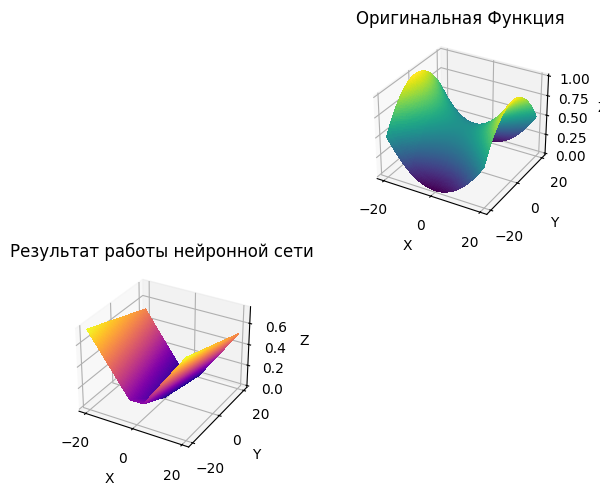

In [67]:
# Обучение и визуализация для каждого оптимизатора
# Adam
learning_rate = 0.0000001
epochs = 1000
batch_size = 16
model = NN(input_size, hidden_size, output_size, learning_rate, activation_function='prelu')
optimizer = AdamOptimizer(learning_rate=0.0002)
loss_history_adam = model.train(np.ravel(X), np.ravel(Y), np.ravel(Z), epochs, optimizer, batch_size)
Z_nn_adam = model.predict(np.column_stack((np.ravel(X), np.ravel(Y)))).reshape(X.shape)
plot_results(loss_history_adam, 'Adam', X, Y, Z, Z_nn_adam)

Epoch 0 - Loss: 0.3028
Epoch 50 - Loss: 0.0931
Epoch 100 - Loss: 0.0942
Epoch 150 - Loss: 0.0942
Epoch 200 - Loss: 0.0942
Epoch 250 - Loss: 0.0941
Epoch 300 - Loss: 0.0941
Epoch 350 - Loss: 0.0941
Epoch 400 - Loss: 0.0942
Epoch 450 - Loss: 0.0942
Epoch 500 - Loss: 0.0942
Epoch 550 - Loss: 0.0942
Epoch 600 - Loss: 0.0941
Epoch 650 - Loss: 0.0941
Epoch 700 - Loss: 0.0942
Epoch 750 - Loss: 0.0942
Epoch 800 - Loss: 0.0942
Epoch 850 - Loss: 0.0942
Epoch 900 - Loss: 0.0941
Epoch 950 - Loss: 0.0941


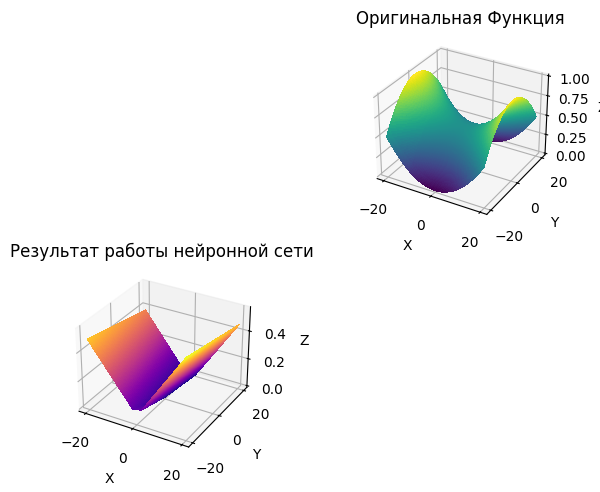

In [61]:
# AdaGrad
learning_rate = 0.000001
hidden_size = 2
epochs = 1000
batch_size = 16
model = NN(input_size, hidden_size, output_size, learning_rate, activation_function='prelu')
optimizer = AdaGradOptimizer(learning_rate=0.003)
loss_history_adagrad = model.train(np.ravel(X), np.ravel(Y), np.ravel(Z), epochs, optimizer, batch_size)
Z_nn_adagrad = model.predict(np.column_stack((np.ravel(X), np.ravel(Y)))).reshape(X.shape)
plot_results(loss_history_adagrad, 'AdaGrad', X, Y, Z, Z_nn_adagrad)

Epoch 0 - Loss: 0.5208
Epoch 50 - Loss: 0.5217
Epoch 100 - Loss: 0.5226
Epoch 150 - Loss: 0.5236
Epoch 200 - Loss: 0.5245
Epoch 250 - Loss: 0.5254
Epoch 300 - Loss: 0.5263
Epoch 350 - Loss: 0.5273
Epoch 400 - Loss: 0.5282
Epoch 450 - Loss: 0.5292
Epoch 500 - Loss: 0.5301
Epoch 550 - Loss: 0.5311


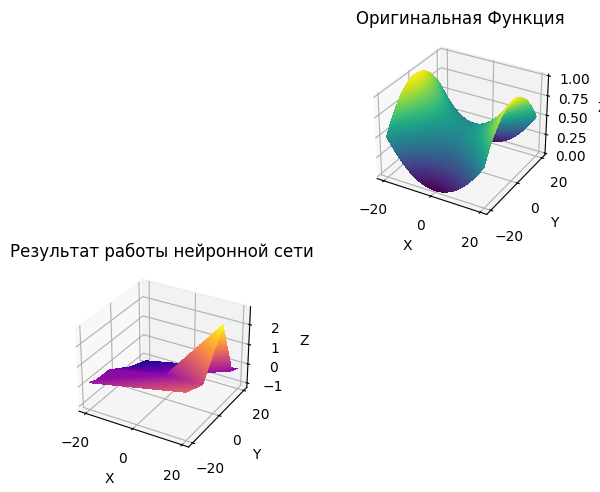

In [139]:
# Nesterov
learning_rate = 0.00000002
epochs = 600
hidden_size = 2
batch_size = 128
model = NN(input_size, hidden_size, output_size, learning_rate, activation_function='prelu')
optimizer = NesterovOptimizer(learning_rate=learning_rate, momentum=0.4)
loss_history_nesterov = model.train(np.ravel(X), np.ravel(Y), np.ravel(Z), epochs, optimizer, batch_size)
Z_nn_nesterov = model.predict(np.column_stack((np.ravel(X), np.ravel(Y)))).reshape(X.shape)
plot_results(loss_history_nesterov, 'Nesterov', X, Y, Z, Z_nn_nesterov)